# 05 - Anomaly Detection (Phát hiện điểm bất thường)

Theo yêu cầu của Đề tài 10, do không áp dụng học bán giám sát (Semi-supervised), nhánh thay thế bắt buộc là Khai phá điểm bất thường (Anomaly Mining).
Notebook này phân tích các cấu hình hành vi tiêu thụ điện năng hàng ngày để tìm ra các "ngày bất thường" (tiêu thụ quá cao đột biến hoặc thấp đột biến do đi vắng/sự cố).

In [1]:
import sys
sys.path.append('..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from src.data.loader import load_config
from src.features.builder import create_daily_profiles
from src.mining.anomaly import detect_anomalies_isolation_forest, plot_anomalies_profile, get_anomaly_insights
from src.visualization.plots import setup_plot_style

setup_plot_style()
# %matplotlib inline

## 1. Tải dữ liệu và chuẩn bị cấu hình tính năng hàng ngày

In [2]:
# Load configuration
config = load_config('../configs/params.yaml')

# Load processed data
df = pd.read_csv('../data/processed/cleaned_data.csv', index_col=0, parse_dates=True)
print(f"Loaded {len(df)} records")

# Tạo profiles hàng ngày giống như phần clustering đã làm
daily_profiles = create_daily_profiles(df)
print(f"Created {len(daily_profiles)} daily profiles")

Loaded 2075259 records


C:\Nam_3\Ky 2\BTL 4\notebooks\..\src\features\builder.py:94: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  df_hourly = df[['Global_active_power']].resample('H').mean().dropna()


Created 1440 daily profiles
Created 1440 daily profiles


## 2. Xây dựng mô hình Isolation Forest để tìm ngày bất thường

In [3]:
# Sử dụng các đặc trưng phân bố trong ngày và tổng tiêu thụ
hourly_cols = [f'hour_{i}' for i in range(24)]
aggregate_cols = ['total_consumption', 'max_consumption', 'min_consumption']
features = hourly_cols + aggregate_cols

# Thực hiện detect (tỷ lệ bất thường dự kiến 5%)
df_anomalies = detect_anomalies_isolation_forest(daily_profiles, features, contamination=0.05)
print("Hoàn thành phát hiện bất thường!")

Hoàn thành phát hiện bất thường!


## 3. Visualize & Trích xuất Insights

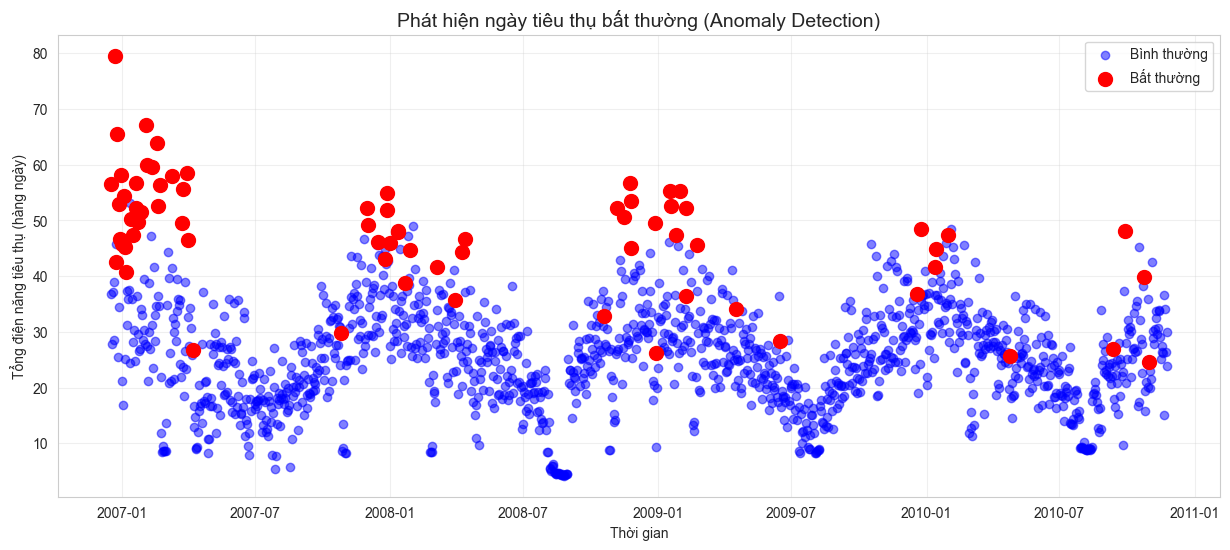

In [4]:
# Vẽ biểu đồ
fig = plot_anomalies_profile(df_anomalies)
plt.show()

# Lưu biểu đồ
import os
os.makedirs('../outputs/figures/', exist_ok=True)
fig.savefig('../outputs/figures/anomaly_detection.png', bbox_inches='tight')

In [5]:
# Hiển thị Insight
insights = get_anomaly_insights(df_anomalies)
print(insights)

# Lưu ra file kết quả
os.makedirs('../outputs/tables/', exist_ok=True)
with open('../outputs/tables/anomaly_insights.txt', 'w', encoding='utf-8') as f:
    f.write(insights)

Phân tích Bất thường:\n- Tổng số ngày quan sát: 1440\n- Số ngày bất thường phát hiện được: 72 (5.00%)\n- Mức tiêu thụ trung bình ngày bình thường: 25.03\n- Mức tiêu thụ trung bình ngày bất thường: 47.63\n=> Đa số các điểm bất thường là những ngày tiêu thụ CAO đột biến (có thể do lễ tết, thời tiết cực đoan, hoặc hệ thống làm mát/sưởi ấm hoạt động quá công suất).
